In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [35]:
before = pd.read_csv(Path.cwd().parent / 'electricity_demand_before_industrial_scaling.csv', index_col=0)
after = pd.read_csv(Path.cwd().parent / 'electricity_demand_after_industrial_scaling.csv', index_col=0)
industry_elec_loads = pd.read_csv(Path.cwd().parent / 'industry_elec_loads.csv', index_col=0)
before = before.sum(axis=1)
after = after.sum(axis=1)
industry_elec_loads = industry_elec_loads.sum().sum() * 1e-3

num = 300
before = before * 1e-3
after = after * 1e-3

before.index = range(len(before))
after.index = range(len(after))

In [36]:
x0, x1 = before.index[0], num-1

In [37]:
xfill = np.linspace(x0, x1, num)

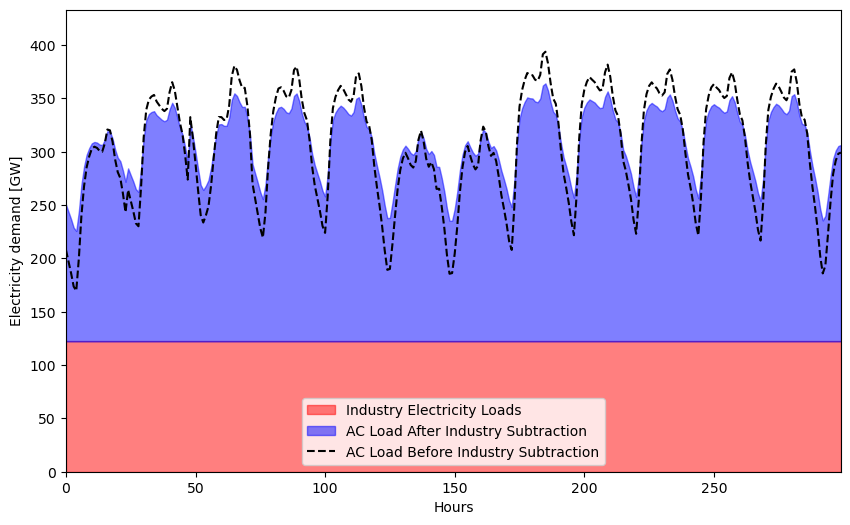

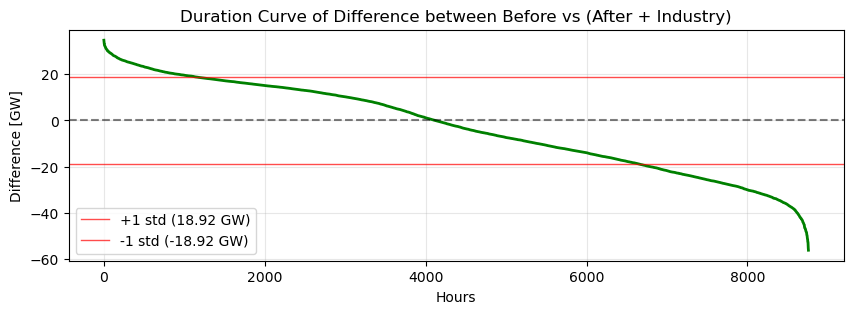

In [45]:
# First figure: time series comparison
fig, ax = plt.subplots(figsize=(10, 6))

# Only plot first num timesteps
before_plot = before.iloc[:num]
after_plot = after.iloc[:num]

ax.fill_between(
    xfill,
    np.zeros(num),
    np.ones(num) * industry_elec_loads,
    color='red',
    alpha=0.5,
    label='Industry Electricity Loads'
    )


ax.fill_between(
    xfill,
    np.ones(num) * industry_elec_loads,
    after_plot.values + np.ones(num) * industry_elec_loads,
    color='blue',
    alpha=0.5, label='AC Load After Industry Subtraction')

before_plot.plot(ax=ax, label='AC Load Before Industry Subtraction', color='k', linestyle='--')

plt.legend(loc='lower center')

ax.set_xlim(x0, x1)
ax.set_ylim(0, 1.1 * before_plot.max())

ax.set_xlabel('Hours')
ax.set_ylabel('Electricity demand [GW]')

plt.show()

after_plus_industry = after + industry_elec_loads
difference = before - after_plus_industry

# Sort differences in descending order for duration curve
difference_sorted = difference.sort_values(ascending=False).values
hours = np.arange(len(difference_sorted))

# Calculate standard deviation
std_dev = difference.std()

fig2, ax2 = plt.subplots(figsize=(10, 3))
ax2.plot(hours, difference_sorted, color='green', linewidth=2)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax2.axhline(y=std_dev, color='red', linestyle='-', linewidth=1, alpha=0.7, label=f'+1 std ({std_dev:.2f} GW)')
ax2.axhline(y=-std_dev, color='red', linestyle='-', linewidth=1, alpha=0.7, label=f'-1 std ({-std_dev:.2f} GW)')
ax2.set_xlabel('Hours')
ax2.set_ylabel('Difference [GW]')
ax2.set_title('Duration Curve of Difference between Before vs (After + Industry)')
ax2.grid(True, alpha=0.3)
ax2.legend()
plt.show()
